In [20]:
import warnings

from ipywidgets import IntSlider

warnings.filterwarnings("ignore")

In [21]:
import pandas as pd
import drawdata
import matplotlib.pyplot as plt

In [22]:
widget = drawdata.ScatterWidget()
widget

In [54]:
data = widget.data_as_pandas

In [55]:
data.head()

,x,y,color,label,batch
0,109.398735,261.518175,#1f77b4,a,0
1,141.666327,359.863083,#1f77b4,a,0
2,257.271797,306.421736,#1f77b4,a,0
3,323.282443,288.845384,#1f77b4,a,0
4,331.831741,249.745762,#1f77b4,a,0


In [56]:
data.to_csv("datasets/simple.csv", index=False)

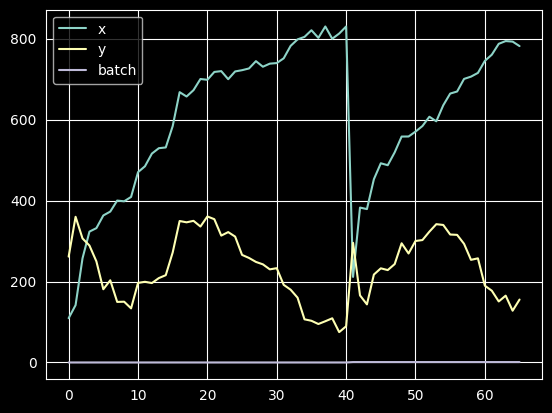

In [57]:
data.plot()

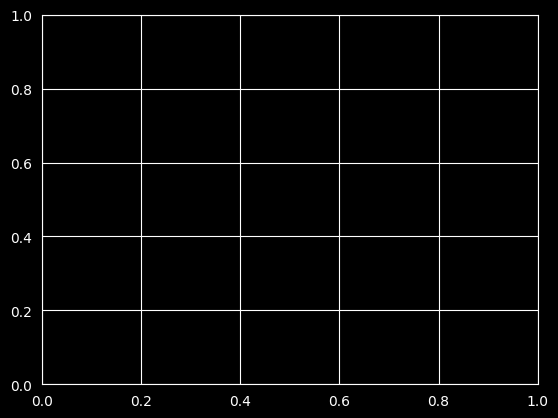

In [27]:
fig, ax = plt.subplots()
data.plot.scatter(x="x", y="y", ax=ax)

plt.show()

# Explore Bagging

6 different random forest with single tree


In [29]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

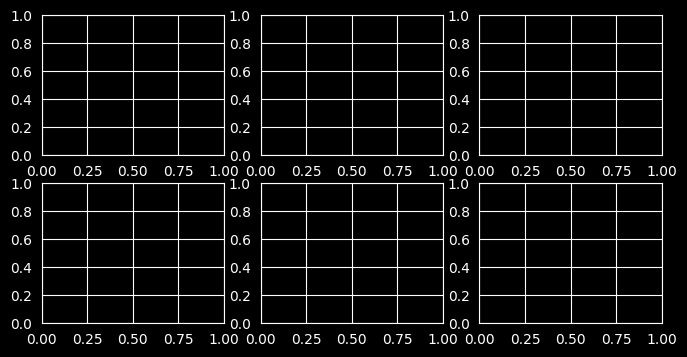

In [30]:
layout = """
123
456
"""

fig, axs = plt.subplot_mosaic(layout, figsize=(8, 4))
n_trees = [1] * 6

data = pd.read_csv("datasets/simple.csv")

for i, n_tree in enumerate(n_trees, start=1):
    ax = axs[str(i)]
    data.plot.scatter(x="x", y="y", ax=ax, title=f"n_tree={n_tree}, seed={i}", s=1)

    clf = RandomForestRegressor(n_estimators=n_tree, max_depth=3, max_samples=0.01, random_state=i)
    clf.fit(data[["x"]], data["y"])

    x = pd.DataFrame({
        "x": np.linspace(data.x.min(), data.x.max(), 100),
    })
    y = clf.predict(x)
    ax.plot(x, y, c="red")

fig.tight_layout()


## random forest vs single tree
- przykład dlaczego random forest minimalizuje overfiting

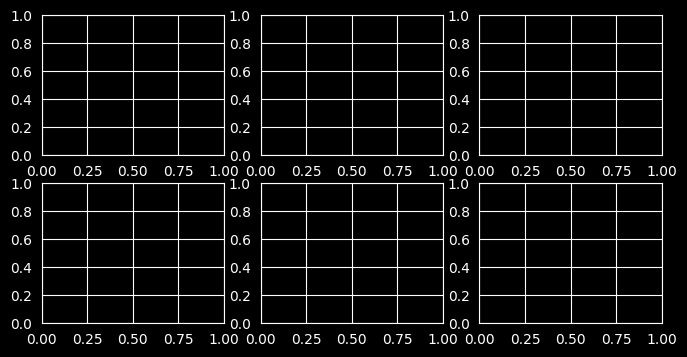

In [31]:
layout = """
123
456
"""

fig, axs = plt.subplot_mosaic(layout, figsize=(8, 4))
n_trees = [1, 2, 5, 10, 20, 50]

data = pd.read_csv("datasets/simple.csv")

for i, n_tree in enumerate(n_trees, start=1):
    ax = axs[str(i)]
    data.plot.scatter(x="x", y="y", ax=ax, title=f"n_tree={n_tree}", s=1)

    clf = RandomForestRegressor(n_estimators=n_tree, max_depth=3, max_samples=0.01, random_state=42)
    clf.fit(data[["x"]], data["y"])

    x = pd.DataFrame({
        "x": np.linspace(data.x.min(), data.x.max(), 100),
    })

    for i, tree in enumerate(clf.estimators_):
        y = tree.predict(x)
        ax.plot(x, y, c="grey", alpha=0.9)

    y = clf.predict(x)
    ax.plot(x, y, c="red")

fig.tight_layout()


In [33]:
def plot_random_forest(data_path, max_depth, max_samples):
    layouts = """
    123
    4456
    """
    plt.close('all')

    fig, axs = plt.subplot_mosaic(layouts, figsize=(18, 4))
    n_trees = [1, 2, 5, 10, 20, 50]

    data = pd.read_csv(data_path)

    for i, n_tree in enumerate(n_trees, start=1):
        ax = axs[str(i)]
        data.plot.scatter(x="x", y="y", ax=ax, title=f"n_tree={n_tree}", s=1)

        clf = RandomForestRegressor(n_estimators=n_tree, max_depth=max_depth, max_samples=max_samples, random_state=42)
        clf.fit(data[["x"]], data["y"])

        x = pd.DataFrame({
            "x": np.linspace(data.x.min(), data.x.max(), 100),
        })

        for i, tree in enumerate(clf.estimators_):
            y = tree.predict(x)
            ax.plot(x, y, c="grey", alpha=0.9)

        y = clf.predict(x)
        ax.plot(x, y, c="red")

    fig.tight_layout()
    plt.show()

In [34]:
from ipywidgets import FloatSlider, IntSlider, interact

max_depth_slider = IntSlider(min=1, max=3, step=1, value=3, description="Max Depth")
max_samples_slider = FloatSlider(min=0.01, max=1.0, step=0.01, value=0.1, description="Max Samples")

interact(
    plot_random_forest,
    data_path = "datasets/simple.csv",
    max_depth = max_depth_slider,
    max_samples = max_samples_slider,
)


<Figure size 1800x400 with 0 Axes>

---


In [36]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from sklearn import set_config

In [37]:
set_config(transform_output="pandas")

In [38]:
adult_data = fetch_openml(data_id=1590)
X = adult_data.data
y = adult_data.target

In [39]:
(
    X
    .assign(y=y)
    .to_parquet("datasets/adult_copy.parquet")
)

In [40]:
X.isna().sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
dtype: int64

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [42]:
categorical_features = X.select_dtypes(include=["category"]).columns
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

In [43]:
categorical_transformer.fit_transform(X[categorical_features])

,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,workclass_missing,education_10th,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,native-country_missing
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
48838,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
48839,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
48840,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [44]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier


In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=43, stratify=y)

In [46]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features)
    ]
)
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, max_depth=20, max_samples=0.1, random_state=42))
])

pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.832


In [47]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1)),
])

param_distributions = {
    "classifier__n_estimators": np.arange(50, 801, 50),
    "classifier__max_depth": [None, 3, 5, 8, 12, 20],
    "classifier__min_samples_leaf": [1, 2, 4, 8],
    "classifier__max_features": ["sqrt", "log2", None],
}

rnd = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)

rnd.fit(X_train, y_train)

print("Best params:", rnd.best_params_)
print("Best CV accuracy:", rnd.best_score_)

y_pred = rnd.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))

pd.DataFrame(rnd.cv_results_).sort_values("rank_test_score").head(10)[
    ["mean_test_score", "std_test_score", "mean_train_score", "params"]
]


KeyboardInterrupt



In [ ]:
# Boosting and Gradient Boosting

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.linear_model import LinearRegression

import warnings

warnings.filterwarnings("ignore")

In [ ]:
layout = """
123
456
"""

fig, axs = plt.subplot_mosaic(layout, figsize=(8, 4))
n_trees = [1, 2, 5, 10, 20, 50]

data = pd.read_csv("datasets/simple.csv")

for i, n_tree in enumerate(n_trees, start=1):
    ax = axs[str(i)]
    data.plot.scatter(x="x", y="y", ax=ax, title=f"n_tree={n_tree}", s=1)

    clf = AdaBoostRegressor(n_estimators=n_tree,estimator=DecisionTreeRegressor(max_depth=3), random_state=42)
    clf.fit(data[["x"]], data["y"])

    x = pd.DataFrame({
        "x": np.linspace(data.x.min(), data.x.max(), 100),
    })

    y = clf.estimators_[-1].predict(x)
    ax.plot(x, y, c="grey", alpha=0.9)

    ax.plot(x, y, c="red")

fig.tight_layout()

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier



In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features)
    ]
)
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, max_depth=20, max_samples=0.1, random_state=42))
])

pipeline.fit(X_train, y_train)

accuracy = accuracy_score(y_test, pipeline.predict(X_test))
print(f"Model Accuracy: {accuracy:.3f}")

# Gradient boosting


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
layout = """
123
456
"""

fig, axs = plt.subplot_mosaic(layout, figsize=(8, 4))
n_trees = [1, 2, 5, 10, 20, 50]

data = pd.read_csv("datasets/simple.csv")

for i, n_tree in enumerate(n_trees, start=1):
    ax = axs[str(i)]
    data.plot.scatter(x="x", y="y", ax=ax, title=f"n_tree={n_tree}", s=1)

    clf = GradientBoostingRegressor(n_estimators=n_tree, max_depth=3, random_state=42)
    clf.fit(data[["x"]], data["y"])

    x = pd.DataFrame({
        "x": np.linspace(data.x.min(), data.x.max(), 100),
    })

    y = clf.estimators_.flatten()[-1].predict(x)
    ax.plot(x, y, c="pink", alpha=0.9)
    y=clf.predict(x)
    ax.plot(x, y, c="red")

fig.tight_layout()

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier())
])

pipeline.fit(X_train, y_train)

accuracy = accuracy_score(y_test, pipeline.predict(X_test))
print(f"Model Accuracy: {accuracy:.3f}")

# HyperParameter Tuning for Boosting Models

1. Wiedza domenowa -> ogranicz przestrzeń
2. RandomSearch -> eksplkoruj globalnie
3. GridSearch -> dorexyzuj lokalnie
4. Pipline -> kontroluj leakage
5. CV -> stabilizuj porównanie
6. Multi-metric -> świadome kompromisy
7. Analiza wyników -> ucz się, nie tylko wybieraj

In [ ]:
n_estimators_space = [50, 100, 150, 200, 300] # pojemność modelu
learning_rate_space = [0.03, 0.05, 0.]
max_depth_space = [2, 3]

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import  RandomizedSearchCV
from sklearn.metrics import make_scorer, accuracy_score, f1_score


In [51]:
pipeline = Pipeline(steps =[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

param_distributions = {
    "classifier__n_estimators": n_estimators_space,
    "classifier__learning_rate": learning_rate_space,
    "classifier__max_depth":max_depth_space,
    "classifier__subsample": [0.7, 0.8, 0.9, 1.0]
}

scoring = {
    "accuracy": make_scorer(accuracy_score),
    "f1": make_scorer(f1_score, avreage="weighted") # 2 * (precison * recall) / (precison + recall) ,
}
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring=scoring,
    refit="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__learning_rate': [0.03, 0.05, ...], 'classifier__max_depth': [2, 3], 'classifier__n_estimators': [50, 100, ...], 'classifier__subsample': [0.7, 0.8, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': make_scorer(a...hod='predict'), 'f1': make_scorer(f...eage=weighted)}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be t

In [ ]:
best_params = random_search.best_params_
grid_param_space = {
    "classifier__n_estimators": [
        best_params["classifier__n_estimators"] - 50,
        best_params["classifier__n_estimators"],
        best_params["classifier__n_estimators"]
    ],
    "classifier__learning_rate": [
        best_params["classifier__learning_rate"] * 0.8,
        best_params["classifier_learning_rate"],
        best_params["classifier__learning_rate"] * 1.2,
    ],
    "classifier__max_depth": [best_params["classifier__max_depth"]],
    "classifier__subsample": [best_params["classifier__subsample"]]
}

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=grid_param_space,
    scoring=scoring,
    refit="f1",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

In [50]:
results = pd.DataFrame(grid_search.cv_results_)
results[[
    "mean_test_accuracy",
    "mean_test_f1",
    "param_classifier__n_estimators"
    "param_classifier__learning_rate"
    "param_classifier__max_depth"
    "param_classifier__subsample"
]].sort_values("mean_test_f1", ascending=False)

NameError: name 'grid_search' is not defined

In [66]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from xgboost import XGBRegressor, XGBClassifier

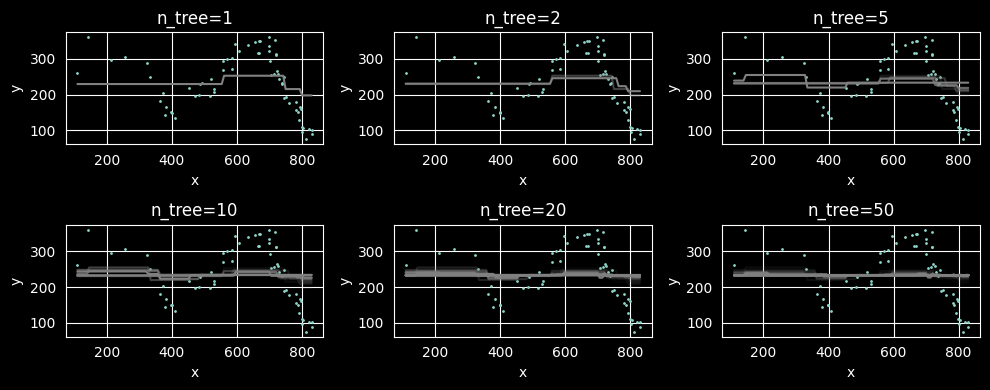

In [62]:
layouts = """
123
456
"""

fig, axs = plt.subplot_mosaic(layouts, figsize=(10, 4))

n_trees = [1, 2, 5, 10, 20, 50]

data = pd.read_csv("datasets/simple.csv")

for i, n_tree in enumerate(n_trees, start=1):
    ax=axs[str(i)]

    data.plot.scatter(x="x", y="y", ax=ax, title=f"n_tree={n_tree}", s=1)
    rf = XGBRegressor(
        n_estimators=n_tree,
        max_depth=2,
        random_state=42,
    )
    rf.fit(data[["x"]], data["y"])
    x = pd.DataFrame({
        "x":  np.linspace(data.x.min(), data.x.max(), 100),
    })
    for z, j in enumerate(range(n_tree)):
        y=rf.predict(x, iteration_range=(j, j+1))
        ax.plot(x, y, c="grey", alpha=(z+1)/ n_tree)

plt.tight_layout()

In [63]:
X_train.dtypes

age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
dtype: object

In [67]:
model = XGBClassifier(
    enable_categorical=True,
)
model.fit(X_train, y_train=='>50K')
accuracy= accuracy_score(y_test=='>50K', model.predict(X_test))
print(f"Model Accuracy: {accuracy:.3f}")

Model Accuracy: 0.873


In [78]:
y_pred = model.predict(X_test)
np.bincount(y_pred)



array([11669,  2984])

In [77]:
f1 = f1_score(y_test=='>50K', model.predict(X_test))
print(f"Model f1: {f1:.3f}")

Model f1: 0.712


In [79]:
model = XGBClassifier(
    enable_categorical=True,
    max_depth=3
)
model.fit(X_train, y_train=='>50K')
accuracy= accuracy_score(y_test=='>50K', model.predict(X_test))
print(f"Model Accuracy: {accuracy:.3f}")
f1 = f1_score(y_test=='>50K', model.predict(X_test))
print(f"Model f1: {f1:.3f}")

Model Accuracy: 0.874
Model f1: 0.712
